In [2]:
import numpy as np
import pandas as pd
import io
import requests

variable         | description
---------------- | -----------
`timestamp`      | 
`score`          | 
`age`            | 
`gender`         |
`age_of_exp`     |
`condition`      | 
`bnk_sta`        |
`fe_exp`         | 
`pc_disc`        | 
`fs_inprac`      | 
`conf_mm`        | 
`conf_prep`      | 
`conf_emer`      | 
`emer_pri`       | 
`conf_infd`      | 
`conf_track`     | 
`plan_largeps`   | 
`conf_save`      |
`conf_goals`     | 

Conduct a quantitative analysis

a. Compute one centrality measure (e.g. mean, mode, median) and one
dispersion measure (e.g. standard deviation, variance, range) on all your
variables. TICK

b. Visualise your data using at least two of the following methods: histogram,
density plot, bar chart, scatter plot, box plot. Do not use pie charts.

c. Run an inferential statistic test that is appropriate to answer your scientific
question. Examples of tests you could run include: t-test, chi-square, linear
regression, correlation, ANOVA.



In [3]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('LBD.code.csv')

df


,timestamp,score_lit,age,gender,age_of_exp,condition,bnk_sta,fe_exp,pc_disc,fs_inprac,conf_mm,conf_prep,conf_emer,emer_pri,conf_infd,conf_track,plan_largeps,conf_save,conf_goals,score_conf
0,5/19/2026 8:37:23,35,35-44,Female,1,1,1,0,0,0,4,3,5,4,4,4,4,5,4,37
1,5/19/2026 9:26:19,50,35-44,Male,1,0,0,0,0,0,3,4,3,5,2,2,3,3,3,28
2,5/19/2026 9:45:34,30,18-24,Female,0,0,0,0,1,0,4,4,5,5,4,4,4,4,4,38
3,5/19/2026 9:55:12,25,18-24,Female,0,0,0,0,1,0,1,1,1,1,1,2,1,1,1,10
4,5/19/2026 10:07:03,35,18-24,Male,1,1,0,0,1,0,3,3,4,2,3,3,5,4,3,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,5/21/2026 18:33:47,45,18-24,Female,0,0,0,0,0,0,2,1,3,1,1,4,2,2,2,18
57,5/21/2026 18:38:42,50,25-34,Male,1,0,0,0,1,0,3,3,5,2,2,1,2,5,1,24
58,5/22/2026 22:46:52,30,45+,Female,2,4,0,0,0,0,4,4,3,1,3,5,1,4,4,29
59,5/28/2026 14:28:22,50,18-24,Female,0,0,0,0,1,0,4,4,4,4,4,4,4,4,2,34


In [28]:
# literacy score + confidence/behaiviour score = financial capability score / 'cap_score
df ['cap_score'] = df['score_lit'] + df['score_conf']

df ['cap_score']

0     72
1     78
2     68
3     35
4     65
      ..
56    63
57    74
58    59
59    84
60    53
Name: cap_score, Length: 61, dtype: int64

In [37]:
import numpy as np
import statsmodels.api as sm

formula_string = "score_lit ~ age_of_exp"

model = sm.formula.ols(formula = formula_string, data = df)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:              score_lit   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     2.755
Date:                Thu, 11 Jun 2026   Prob (F-statistic):              0.102
Time:                        20:03:44   Log-Likelihood:                -227.23
No. Observations:                  61   AIC:                             458.5
Df Residuals:                      59   BIC:                             462.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     35.0749      1.942     18.064      0.0

In [39]:
import numpy as np
import statsmodels.api as sm

formula_string = "score_conf ~ age_of_exp"

model = sm.formula.ols(formula = formula_string, data = df)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:             score_conf   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     3.204
Date:                Thu, 11 Jun 2026   Prob (F-statistic):             0.0786
Time:                        20:04:51   Log-Likelihood:                -203.26
No. Observations:                  61   AIC:                             410.5
Df Residuals:                      59   BIC:                             414.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.5106      1.311     22.516      0.0

In [29]:
import numpy as np
import statsmodels.api as sm

formula_string = "cap_score ~ age_of_exp"

model = sm.formula.ols(formula = formula_string, data = df)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:              cap_score   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     4.944
Date:                Thu, 11 Jun 2026   Prob (F-statistic):             0.0300
Time:                        18:46:56   Log-Likelihood:                -242.76
No. Observations:                  61   AIC:                             489.5
Df Residuals:                      59   BIC:                             493.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     64.5855      2.505     25.787      0.0

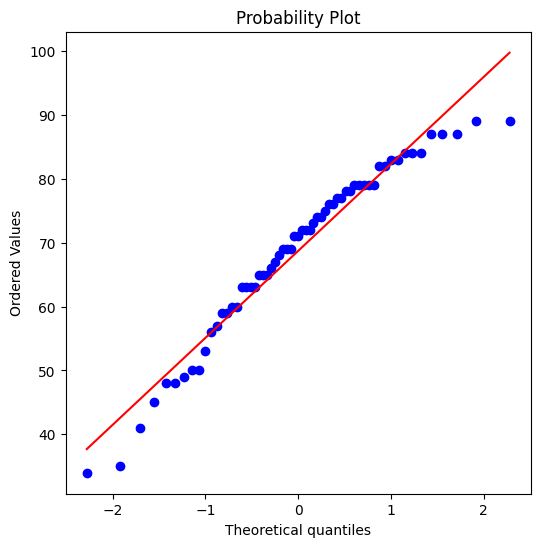

In [36]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

probplot(df['cap_score'], plot = plt)
plt.show();

np.float64(68.70491803278688)

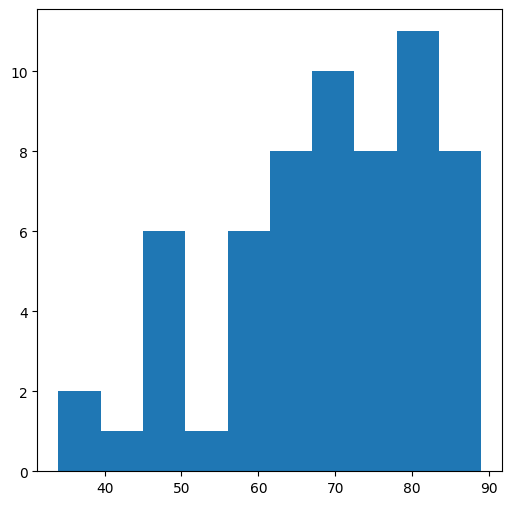

In [32]:
plt.hist(df.cap_score)

df['cap_score'].mean()

np.float64(37.459016393442624)

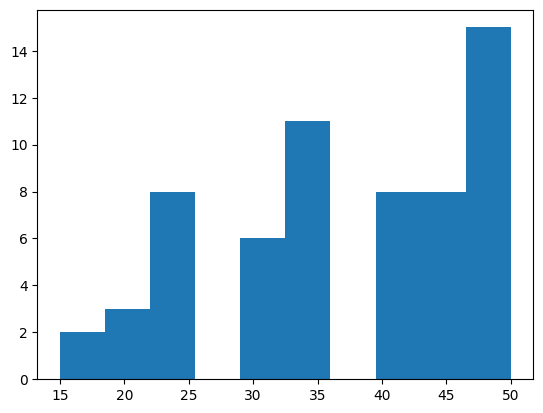

In [5]:
plt.hist(df.score_lit)

df['score_lit'].mean()

np.float64(31.24590163934426)

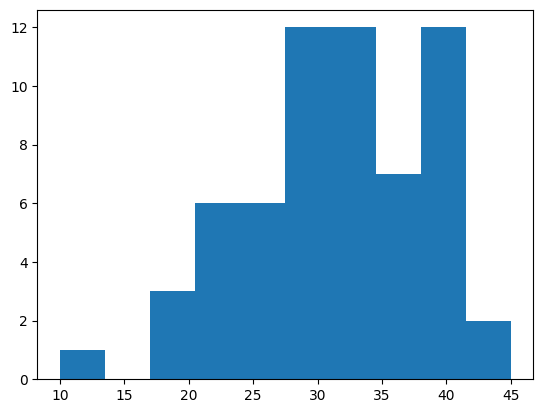

In [6]:
plt.hist(df.score_conf)

df['score_conf'].mean()

np.float64(0.7213114754098361)

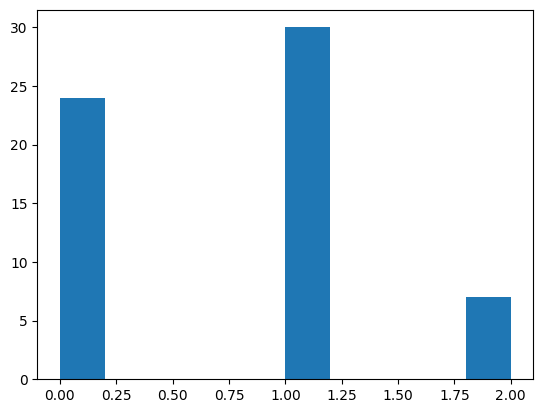

In [7]:
plt.hist(df.age_of_exp)

df['age_of_exp'].mean()

np.float64(0.7868852459016393)

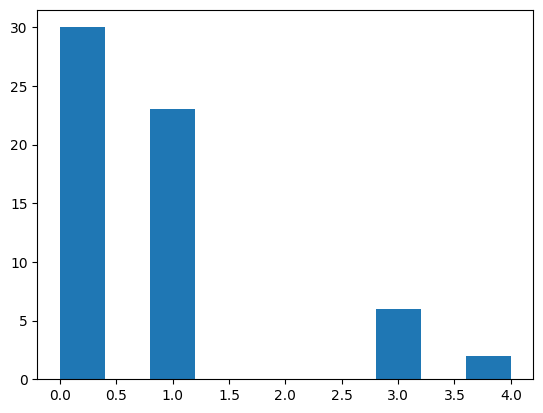

In [8]:
plt.hist(df.condition)

df['pc_disc'].mean()

np.float64(0.16393442622950818)

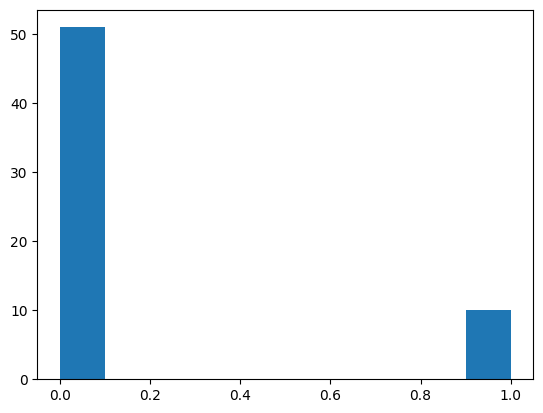

In [9]:
plt.hist(df.bnk_sta)

df['bnk_sta'].mean()

0     0
1     0
2     0
3     0
4     0
     ..
56    0
57    0
58    0
59    0
60    0
Name: fe_exp, Length: 61, dtype: int64

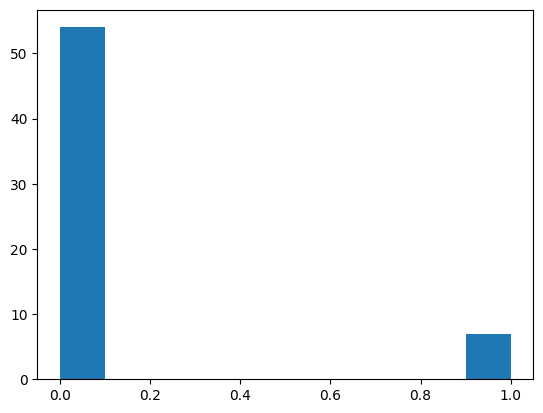

In [10]:
plt.hist(df.fe_exp)

df['fe_exp']

np.float64(0.7868852459016393)

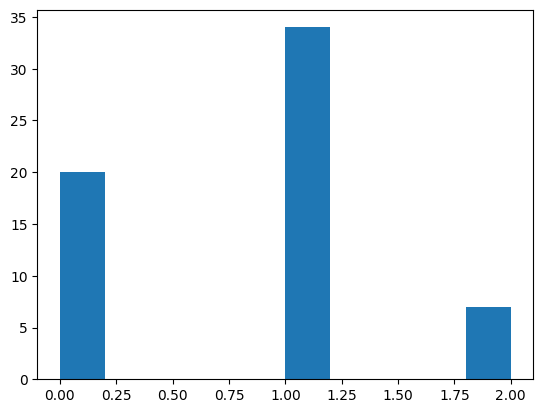

In [11]:
plt.hist(df.pc_disc)

df['pc_disc'].mean()

np.float64(0.4426229508196721)

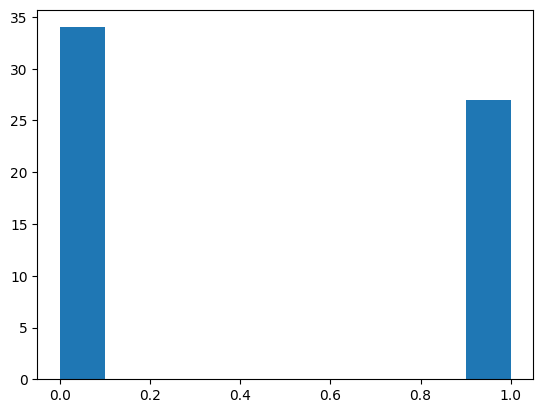

In [12]:
plt.hist(df.fs_inprac)

df['fs_inprac'].mean()

FINANCIAL CONFIDENCE VARIABLES (1-5)

np.float64(3.6557377049180326)

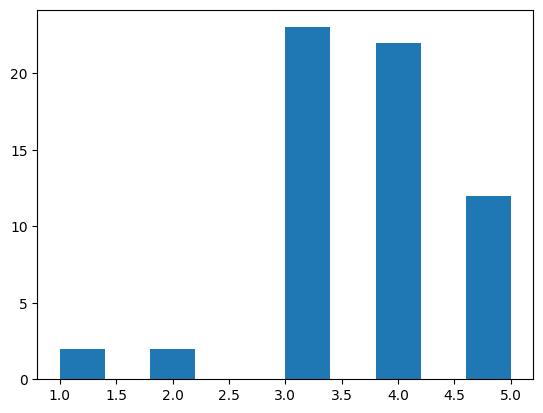

In [13]:
plt.hist(df.conf_mm)

df['conf_mm'].mean()

np.float64(3.3442622950819674)

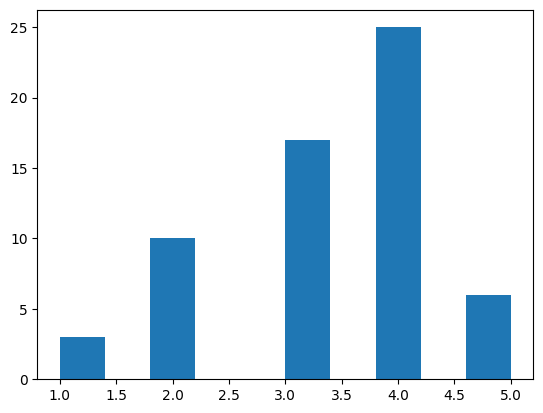

In [14]:
plt.hist(df.conf_prep)

df['conf_prep'].mean()

<bound method Series.mean of 0     5
1     3
2     5
3     1
4     4
     ..
56    3
57    5
58    3
59    4
60    2
Name: conf_emer, Length: 61, dtype: int64>

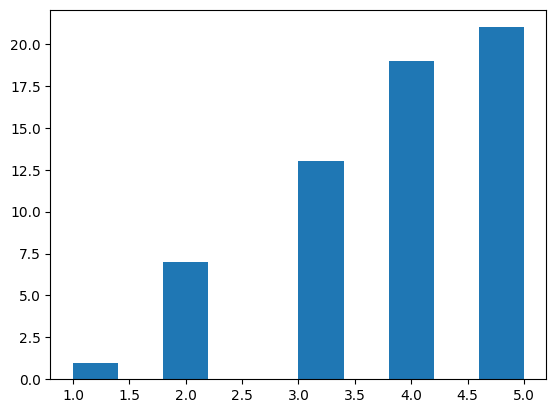

In [15]:
plt.hist(df.conf_emer)

df['conf_emer'].mean

np.float64(2.7540983606557377)

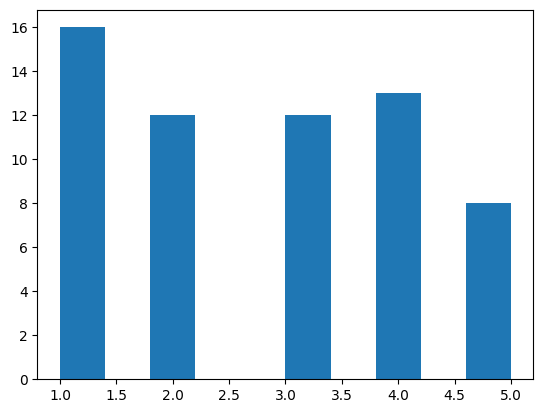

In [16]:
plt.hist(df.emer_pri)

df['emer_pri'].mean()

np.float64(3.6065573770491803)

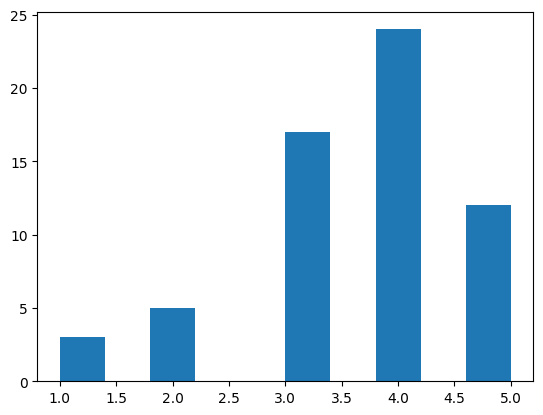

In [17]:
plt.hist(df.conf_infd)

df['conf_infd'].mean()

np.float64(3.622950819672131)

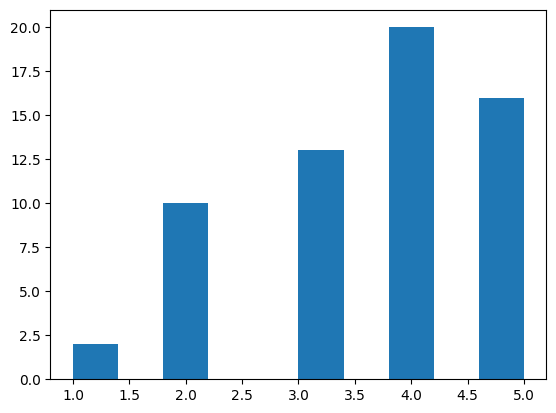

In [18]:
plt.hist(df.conf_track)

df['conf_track'].mean()

np.float64(3.7868852459016393)

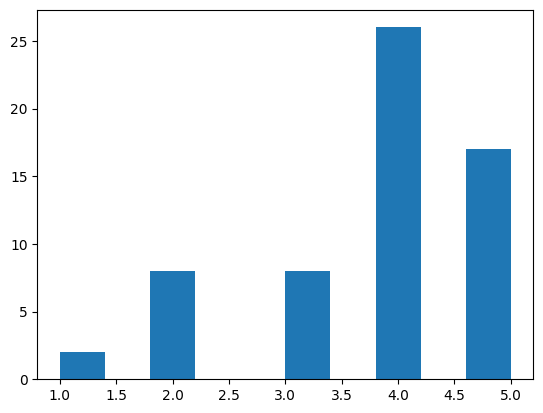

In [19]:
plt.hist(df.plan_largeps)

df['plan_largeps'].mean()

np.float64(3.5901639344262297)

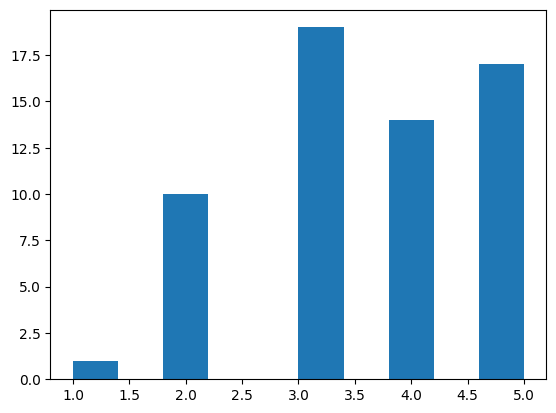

In [20]:
plt.hist(df.conf_save)

df['conf_save'].mean()

<bound method Series.mean of 0     4
1     3
2     4
3     1
4     3
     ..
56    2
57    1
58    4
59    2
60    2
Name: conf_goals, Length: 61, dtype: int64>

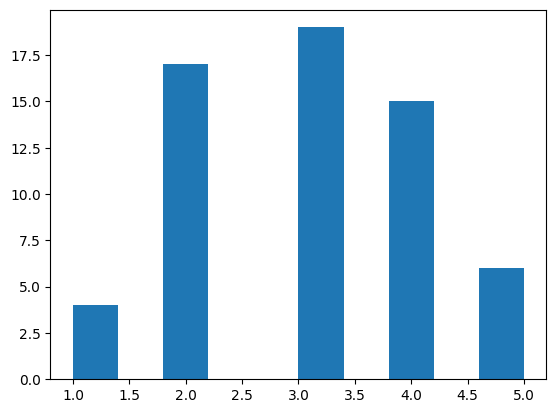

In [21]:
plt.hist(df.conf_goals)

df['conf_goals'].mean

DISPERION

In [22]:
import seaborn as sns
from scipy.stats import norm
import matplotlib.pyplot as plt
%matplotlib inline 
plt.rcParams['figure.figsize'] = (6, 6)

score_hist = sns.distplot(df['score'], norm_hist = True, kde = False, color = 'purple', bins = 8)
x = np.arange(140, 191)                                                  
y = norm.pdf(x, loc = scoremean, scale = scoresd)                                                         
score_hist.plot(x, y, 'purple');

KeyError: 'score'

In [ ]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

probplot(df['score'], plot = plt)
plt.show();

In [ ]:
plt.scatter(df.conf_mm, df.age_of_exp)
plt.xlabel('conf_mm')
plt.ylabel('')

In [ ]:
import seaborn as sns

sns.pairplot(df.iloc[:,12:19])
plt.show();

In [ ]:
plt.scatter(df.score, df.pc_disc)
plt.xlabel('score')
plt.ylabel('pc_disc')
plt.show();

In [ ]:
import matplotlib.pyplot as plt

#prep data
score = df.score
pc_disc = df.pc_disc
# 2. Create Plot
plt.figure(figsize=(8, 5)) # This sets the size of your graph
plt.bar(score,pc_disc , color='black', edgecolor='black')

# 3. Add Details
plt.title('score, parental financial discussion pre16', fontsize=16)
plt.xlabel('score', fontsize=12)
plt.ylabel('pc_disc', fontsize=12)

# 4. Display
plt.show()